In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

print(pd.__version__, yf.__version__)

3.0.6 1.7.0


In [2]:
san = yf.download("SAN.PA", start="2021-08-01", end="2026-08-01")
san.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SAN.PA,SAN.PA,SAN.PA,SAN.PA,SAN.PA
Date,,,,,
2021-08-02,70.015121,70.596226,69.692291,70.378313,1385474
2021-08-03,69.773003,70.588168,69.660012,70.192695,1475426
2021-08-04,68.199173,69.861778,68.070036,69.619651,2598496
2021-08-05,68.699570,68.990119,68.239529,68.279883,1449132
2021-08-06,69.611580,69.708430,68.683424,68.852910,1945661


In [3]:
print(san.shape)
print(san.index.min(), san.index.max())
print(san.isna().sum())

(1281, 5)
2021-08-02 00:00:00 2026-07-31 00:00:00
Price   Ticker
Close   SAN.PA    0
High    SAN.PA    0
Low     SAN.PA    0
Open    SAN.PA    0
Volume  SAN.PA    0
dtype: int64


In [4]:
san["rendement"] = san["Close"].pct_change()
san[["Close", "rendement"]].head()

Price,Close,rendement
Ticker,SAN.PA,
Date,,
2021-08-02,70.015121,NaN
2021-08-03,69.773003,-0.003458
2021-08-04,68.199173,-0.022556
2021-08-05,68.699570,0.007337
2021-08-06,69.611580,0.013275


In [5]:
vol_quotidienne = san["rendement"].std()
vol_annualisee = vol_quotidienne * (252 ** 0.5)
print(vol_quotidienne, vol_annualisee)

0.014688888962426616 0.2331788833825345


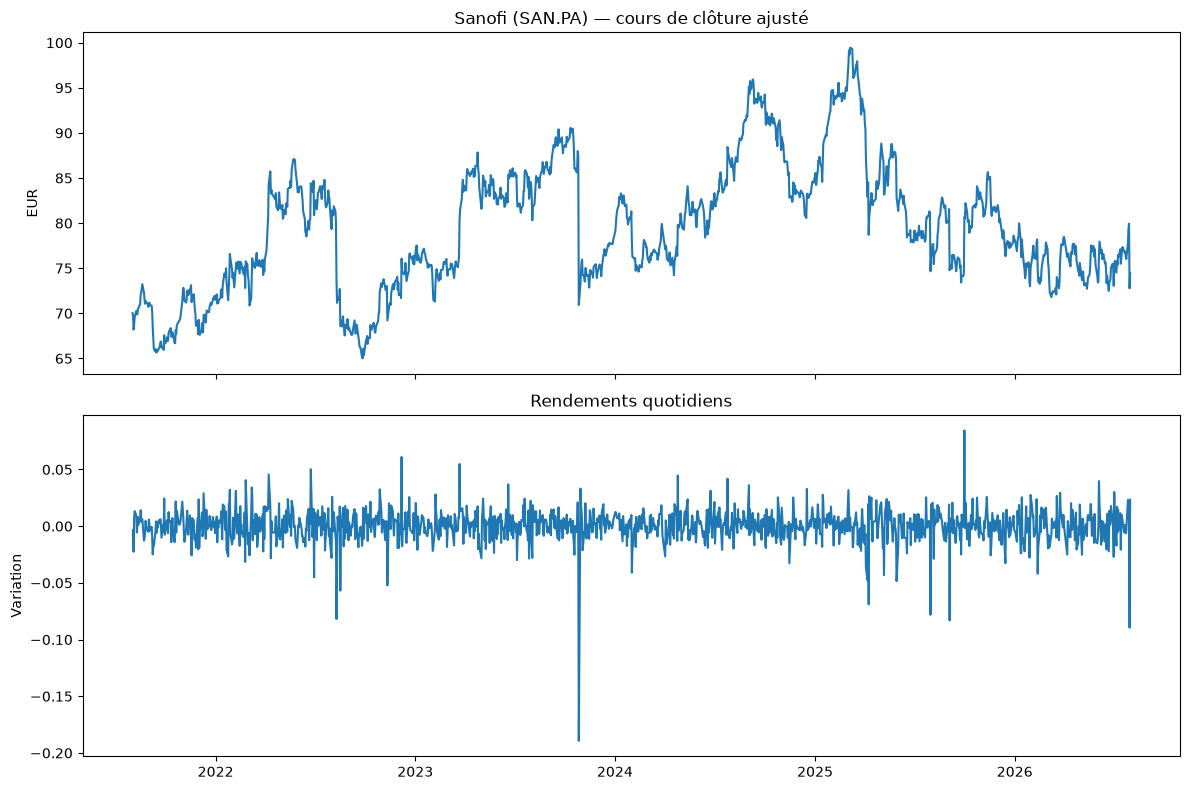

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(san.index, san["Close"])
axes[0].set_title("Sanofi (SAN.PA) — cours de clôture ajusté")
axes[0].set_ylabel("EUR")

axes[1].plot(san.index, san["rendement"])
axes[1].set_title("Rendements quotidiens")
axes[1].set_ylabel("Variation")

plt.tight_layout()
plt.show()

In [7]:
cumul_max = san["Close"].cummax()
san["drawdown"] = san["Close"] / cumul_max - 1

print(san["drawdown"].min())
print(san["drawdown"].idxmin())

-0.27796895930793775
2026-03-09 00:00:00


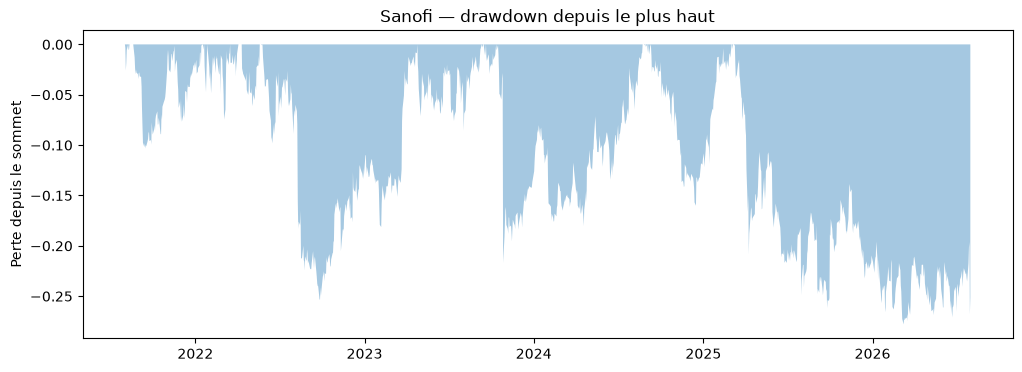

In [8]:
plt.figure(figsize=(12, 4))
plt.fill_between(san.index, san["drawdown"].squeeze(), 0, alpha=0.4)
plt.title("Sanofi — drawdown depuis le plus haut")
plt.ylabel("Perte depuis le sommet")
plt.show()